### 1. Instalacion de Dependencias

In [16]:
%pip install kagglehub pandas sqlite-utils

Note: you may need to restart the kernel to use updated packages.


### 2. Importacion de Dependencias

In [17]:
import sys, subprocess, os, glob
from pathlib import Path
import kagglehub
import pandas as pd
import os, re, sqlite3, pandas as pd

from __future__ import annotations

import argparse
import unicodedata
from pathlib import Path
from typing import List, Dict

import numpy as np

### 3. Creacion de directorios

In [18]:
data_path = Path("data")
data_path.mkdir(exist_ok=True)
print("📁 Carpeta 'data' lista en:", data_path.resolve())
raw_data_path = Path("data/raw_data")
raw_data_path.mkdir(exist_ok=True)
print("📁 Carpeta de datos sin procesar lista en:", data_path.resolve())
normal_data_path = Path("data/normalized_data")
normal_data_path.mkdir(exist_ok=True)
print("📁 Carpeta de datos procesados lista en:", data_path.resolve())

📁 Carpeta 'data' lista en: /workspaces/piv_2025_2/data
📁 Carpeta de datos sin procesar lista en: /workspaces/piv_2025_2/data
📁 Carpeta de datos procesados lista en: /workspaces/piv_2025_2/data


### 4. Descarga de DataSets

In [19]:
datasets = [
    'fredericksalazar/global-imports-goods-and-services-1960-present',
    'fredericksalazar/global-exports-of-goods-and-services-1960-present',
    'fredericksalazar/pib-gdp-global-by-countries-since-1960-to-2021',
    'fredericksalazar/global-inflation-rate-1960-present',
]

for ds in datasets:
    print(f"\n⬇️ Descargando: {ds}")
    try:
        path = kagglehub.dataset_download(ds)
        print("✅ Descargado en:", path)
        # Mover a la carpeta db (opcional, según preferencia)
        os.system(f"cp -r '{path}'/* '{raw_data_path}/' 2>/dev/null || xcopy '{path}' '{raw_data_path}' /E /I /Y")
    except Exception as e:
        print("❌ Error descargando", ds, "->", e)



⬇️ Descargando: fredericksalazar/global-imports-goods-and-services-1960-present


✅ Descargado en: /home/codespace/.cache/kagglehub/datasets/fredericksalazar/global-imports-goods-and-services-1960-present/versions/1

⬇️ Descargando: fredericksalazar/global-exports-of-goods-and-services-1960-present
✅ Descargado en: /home/codespace/.cache/kagglehub/datasets/fredericksalazar/global-exports-of-goods-and-services-1960-present/versions/1

⬇️ Descargando: fredericksalazar/pib-gdp-global-by-countries-since-1960-to-2021
✅ Descargado en: /home/codespace/.cache/kagglehub/datasets/fredericksalazar/pib-gdp-global-by-countries-since-1960-to-2021/versions/4

⬇️ Descargando: fredericksalazar/global-inflation-rate-1960-present
✅ Descargado en: /home/codespace/.cache/kagglehub/datasets/fredericksalazar/global-inflation-rate-1960-present/versions/1


### 5. Normalizando DataSets
* Se procedio con ajustar los datasets de separacion errada de ; a ,
* Los campos en blanco ('', ' ', 'NA', 'NaN', 'nan') fueron rellenados

In [20]:
import os
import glob
import pandas as pd
import numpy as np

# Rutas base
raw_data_path = "data/raw_data"
normal_data_path = "data/normalized_data"
os.makedirs(normal_data_path, exist_ok=True)

# Recomendación de pandas para el warning de downcasting:
pd.set_option('future.no_silent_downcasting', True)

THRESHOLD_EMPTY_ROW = 0.5

def detect_sep(path, default=','):
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        head = f.readline()
    if ';' in head and ',' not in head:
        return ';'
    return default

for file in os.listdir(raw_data_path):
    if not file.lower().endswith(".csv"):
        continue

    path = os.path.join(raw_data_path, file)
    sep = detect_sep(path)
    print(f"📄 Procesando {file} (separador detectado: '{sep}')")

    # 1) Cargar como texto para limpiar sin conflictos de tipo
    try:
        df = pd.read_csv(
            path,
            sep=sep,
            dtype=str,
            encoding='utf-8',
            na_values=['', ' ', 'NA', 'NaN', 'nan']
        )
    except Exception as e:
        print(f"⚠️ Error leyendo {file}: {e}")
        continue

    # 2) Vacíos → NA
    df = df.replace(r'^\s*$', pd.NA, regex=True)
    df = df.infer_objects(copy=False)

    # 3) Métrica de vacíos
    empty_total = df.isna().sum().sum()
    print(f"🔍 Campos vacíos detectados: {empty_total}")

    # 4) Eliminar filas con >50% vacíos
    df_clean = df[df.isna().mean(axis=1) < THRESHOLD_EMPTY_ROW].copy()

    # 5) Intentar convertir a numérico si ≥60% de la columna se puede convertir
    for col in df_clean.columns:
        as_num = pd.to_numeric(df_clean[col], errors='coerce')
        if as_num.notna().mean() >= 0.6:
            df_clean[col] = as_num

    # 6) Rellenar SOLO texto con "N/A" (numéricas quedan con NaN)
    obj_cols = df_clean.select_dtypes(include=['object']).columns
    if len(obj_cols):
        df_clean.loc[:, obj_cols] = df_clean.loc[:, obj_cols].fillna("N/A")

    # 7) Asegurar extensión .csv SIEMPRE
    base_name = os.path.splitext(file)[0] + ".csv"
    out_path = os.path.join(normal_data_path, base_name)

    # 8) Guardar con comas
    df_clean.to_csv(out_path, index=False, sep=',', encoding='utf-8', lineterminator='\n')
    print(f"✅ Guardado normalizado: {out_path}\n")

# Vista previa rápida de los CSV normalizados
try:
    csvs = glob.glob("data/normalized_data/*.csv", recursive=True)
    print(f"\nSe encontraron {len(csvs)} archivos CSV normalizados.")
    for csv in csvs[:5]:
        print("\n🔍 Vista previa →", csv)
        display(pd.read_csv(csv, nrows=5))
except Exception as e:
    print("\n(No se pudo mostrar vista previa de CSVs):", e)


📄 Procesando global_inflation_organizations.csv (separador detectado: ',')
🔍 Campos vacíos detectados: 3328
✅ Guardado normalizado: data/normalized_data/global_inflation_organizations.csv

📄 Procesando export_goods_services_countries_dataset.csv (separador detectado: ',')
🔍 Campos vacíos detectados: 13440
✅ Guardado normalizado: data/normalized_data/export_goods_services_countries_dataset.csv

📄 Procesando countries_gdp_hist.csv (separador detectado: ';')
🔍 Campos vacíos detectados: 0
✅ Guardado normalizado: data/normalized_data/countries_gdp_hist.csv

📄 Procesando global_inflation_countries.csv (separador detectado: ',')
🔍 Campos vacíos detectados: 13440
✅ Guardado normalizado: data/normalized_data/global_inflation_countries.csv

📄 Procesando import_goods_services_countries_dataset.csv (separador detectado: ',')
🔍 Campos vacíos detectados: 13440
✅ Guardado normalizado: data/normalized_data/import_goods_services_countries_dataset.csv

📄 Procesando imports_goods_services_organizations.c

,country_name,country_code,region,income_group,indicator_name,indicator_code,year,inflation_rate
0,INGRESO MEDIANO,MIC,NaN,AGREGADOS,"INFLACION, PRECIOS AL CONSUMIDOR (% ANUAL)",FP.CPI.TOTL.ZG,1960,0.0
1,INGRESO MEDIANO,MIC,NaN,AGREGADOS,"INFLACION, PRECIOS AL CONSUMIDOR (% ANUAL)",FP.CPI.TOTL.ZG,1961,0.0
2,INGRESO MEDIANO,MIC,NaN,AGREGADOS,"INFLACION, PRECIOS AL CONSUMIDOR (% ANUAL)",FP.CPI.TOTL.ZG,1962,0.0
3,INGRESO MEDIANO,MIC,NaN,AGREGADOS,"INFLACION, PRECIOS AL CONSUMIDOR (% ANUAL)",FP.CPI.TOTL.ZG,1963,0.0
4,INGRESO MEDIANO,MIC,NaN,AGREGADOS,"INFLACION, PRECIOS AL CONSUMIDOR (% ANUAL)",FP.CPI.TOTL.ZG,1964,0.0



🔍 Vista previa → data/normalized_data/export_goods_services_countries_dataset.csv


,country_code,country_name,region,sub_region,intermediate_region,indicator_code,indicator_name,year,exports_of_goods_and_services
0,AFG,AFGANISTAN,ASIA MERIDIONAL,SOUTHERN ASIA,NaN,NE.EXP.GNFS.ZS,EXPORTACIONES DE BIENES Y SERVICIOS (% DEL PIB),1960,0.0
1,AFG,AFGANISTAN,ASIA MERIDIONAL,SOUTHERN ASIA,NaN,NE.EXP.GNFS.ZS,EXPORTACIONES DE BIENES Y SERVICIOS (% DEL PIB),1961,0.0
2,AFG,AFGANISTAN,ASIA MERIDIONAL,SOUTHERN ASIA,NaN,NE.EXP.GNFS.ZS,EXPORTACIONES DE BIENES Y SERVICIOS (% DEL PIB),1962,0.0
3,AFG,AFGANISTAN,ASIA MERIDIONAL,SOUTHERN ASIA,NaN,NE.EXP.GNFS.ZS,EXPORTACIONES DE BIENES Y SERVICIOS (% DEL PIB),1963,0.0
4,AFG,AFGANISTAN,ASIA MERIDIONAL,SOUTHERN ASIA,NaN,NE.EXP.GNFS.ZS,EXPORTACIONES DE BIENES Y SERVICIOS (% DEL PIB),1964,0.0



🔍 Vista previa → data/normalized_data/countries_gdp_hist.csv


,country_code,region_name,sub_region_name,intermediate_region,country_name,income_group,year,total_gdp,total_gdp_million,gdp_variation
0,ABW,AMERICAS,LATIN AMERICA AND THE CARIBBEAN,CARIBBEAN,ARUBA,INGRESO ALTO,1960,0.0,0.0,0.0
1,ABW,AMERICAS,LATIN AMERICA AND THE CARIBBEAN,CARIBBEAN,ARUBA,INGRESO ALTO,1961,0.0,0.0,0.0
2,ABW,AMERICAS,LATIN AMERICA AND THE CARIBBEAN,CARIBBEAN,ARUBA,INGRESO ALTO,1962,0.0,0.0,0.0
3,ABW,AMERICAS,LATIN AMERICA AND THE CARIBBEAN,CARIBBEAN,ARUBA,INGRESO ALTO,1963,0.0,0.0,0.0
4,ABW,AMERICAS,LATIN AMERICA AND THE CARIBBEAN,CARIBBEAN,ARUBA,INGRESO ALTO,1964,0.0,0.0,0.0



🔍 Vista previa → data/normalized_data/global_inflation_countries.csv


,country_code,country_name,region,sub_region,intermediate_region,indicator_code,indicator_name,year,inflation_rate
0,AFG,AFGANISTAN,ASIA MERIDIONAL,SOUTHERN ASIA,NaN,FP.CPI.TOTL.ZG,"INFLACION, PRECIOS AL CONSUMIDOR (% ANUAL)",1960,0.0
1,AFG,AFGANISTAN,ASIA MERIDIONAL,SOUTHERN ASIA,NaN,FP.CPI.TOTL.ZG,"INFLACION, PRECIOS AL CONSUMIDOR (% ANUAL)",1961,0.0
2,AFG,AFGANISTAN,ASIA MERIDIONAL,SOUTHERN ASIA,NaN,FP.CPI.TOTL.ZG,"INFLACION, PRECIOS AL CONSUMIDOR (% ANUAL)",1962,0.0
3,AFG,AFGANISTAN,ASIA MERIDIONAL,SOUTHERN ASIA,NaN,FP.CPI.TOTL.ZG,"INFLACION, PRECIOS AL CONSUMIDOR (% ANUAL)",1963,0.0
4,AFG,AFGANISTAN,ASIA MERIDIONAL,SOUTHERN ASIA,NaN,FP.CPI.TOTL.ZG,"INFLACION, PRECIOS AL CONSUMIDOR (% ANUAL)",1964,0.0



🔍 Vista previa → data/normalized_data/import_goods_services_countries_dataset.csv


,country_code,country_name,region,sub_region,intermediate_region,indicator_code,indicator_name,year,imports_of_goods_and_services
0,AFG,AFGANISTAN,ASIA MERIDIONAL,SOUTHERN ASIA,NaN,NE.IMP.GNFS.ZS,IMPORTACIONES DE BIENES Y SERVICIOS (% DEL PIB),1960,0.0
1,AFG,AFGANISTAN,ASIA MERIDIONAL,SOUTHERN ASIA,NaN,NE.IMP.GNFS.ZS,IMPORTACIONES DE BIENES Y SERVICIOS (% DEL PIB),1961,0.0
2,AFG,AFGANISTAN,ASIA MERIDIONAL,SOUTHERN ASIA,NaN,NE.IMP.GNFS.ZS,IMPORTACIONES DE BIENES Y SERVICIOS (% DEL PIB),1962,0.0
3,AFG,AFGANISTAN,ASIA MERIDIONAL,SOUTHERN ASIA,NaN,NE.IMP.GNFS.ZS,IMPORTACIONES DE BIENES Y SERVICIOS (% DEL PIB),1963,0.0
4,AFG,AFGANISTAN,ASIA MERIDIONAL,SOUTHERN ASIA,NaN,NE.IMP.GNFS.ZS,IMPORTACIONES DE BIENES Y SERVICIOS (% DEL PIB),1964,0.0


### 6. Unificacion de Datos

In [21]:
from __future__ import annotations

import re
import unicodedata
from pathlib import Path
from typing import List, Dict

import numpy as np
import pandas as pd

# Directorios
SRC_DIR = Path("data/normalized_data")
OUT_DIR = Path("data/unified_clean")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Mapeos conocidos ---
T_VALUE_MAP = {
    "imports_of_goods_and_services": "NE.IMP.GNFS.ZS",
    "exports_of_goods_and_services": "NE.EXP.GNFS.ZS",
    "imports_percent_gdp": "NE.IMP.GNFS.ZS",
    "exports_percent_gdp": "NE.EXP.GNFS.ZS",
    "inflation_rate": "FP.CPI.TOTL.ZG",
    "inflation_percent": "FP.CPI.TOTL.ZG",
    "gdp_growth": "NY.GDP.MKTP.KD.ZG",
    "gdp_growth_percent": "NY.GDP.MKTP.KD.ZG",
    "total_gdp_million": "NY.GDP.MKTP.CD_MLN",
    "gdp_current_million": "NY.GDP.MKTP.CD_MLN",
    "total_gdp": "NY.GDP.MKTP.CD_LOCAL",
    "gdp_current_local": "NY.GDP.MKTP.CD_LOCAL",
}

INDICATOR_NAMES = {
    "NE.IMP.GNFS.ZS":      "Imports of goods and services (% of GDP)",
    "NE.EXP.GNFS.ZS":      "Exports of goods and services (% of GDP)",
    "FP.CPI.TOTL.ZG":      "Inflation, consumer prices (annual %)",
    "NY.GDP.MKTP.KD.ZG":   "GDP growth (annual %)",
    "NY.GDP.MKTP.CD_MLN":  "GDP, current (million units in file)",
    "NY.GDP.MKTP.CD_LOCAL":"GDP, current (local units in file)"
}

WB_AGG_CODES = {
    "HIC","MIC","LMC","UMC","LIC","LMY","WLD","EAP","ECA","ECS","LCN","MEA","NAC","SAS","SSA","OED","EMU","EUU",
    "AFE","AFW","ARB","CEB","CSS","EAR","EAS","FCS","HPC","IBD","IBT","IDA","IDB","IDX","LTE","MNA","NRS","PRE","SST","TMN","TSA","TSS"
}

CANONICAL_MAP = {
    "country":"country_name","countryname":"country_name","country_name":"country_name",
    "country_code":"country_code","region":"region","region_name":"region",
    "sub_region":"sub_region","sub_region_name":"sub_region","intermediate_region":"intermediate_region",
    "organization_name":"organization_name","income_group":"income_group",
    "indicator":"indicator_name","indicator_name":"indicator_name","indicator_code":"indicator_code",
    "year":"year",
    "imports_of_goods_and_services":"imports_percent_gdp",
    "exports_of_goods_and_services":"exports_percent_gdp",
    "inflation_rate":"inflation_percent",
    "total_gdp":"gdp_current_local",
    "total_gdp_million":"gdp_current_million",
    "gdp_variation":"gdp_growth_percent",
}

def to_snake(s:str)->str:
    if s is None:
        return s
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    s = s.strip().lower()
    s = re.sub(r'[^\w]+', '_', s)
    s = re.sub(r'_+', '_', s).strip('_')
    if not s:
        s = "col"
    if re.match(r'^\d', s):
        s = f"f_{s}"
    return s

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [to_snake(c) for c in df.columns]
    df = df.rename(columns={c: CANONICAL_MAP.get(c, c) for c in df.columns})
    return df

def detect_value_cols(df: pd.DataFrame):
    # prefer known names
    known = [c for c in df.columns if c in T_VALUE_MAP]
    if known:
        return known
    # else heurística
    meta_like = {"country_code","country_name","region","sub_region","intermediate_region",
                 "income_group","organization_name","indicator_code","indicator_name","year"}
    candidates = [c for c in df.columns if c not in meta_like]
    numericish = []
    for c in candidates:
        try:
            ser = pd.to_numeric(df[c], errors='coerce')
            if ser.notna().mean() > 0.5:
                numericish.append(c)
        except Exception:
            pass
    return numericish

def tag_aggregates_dim_geo(dim_geo: pd.DataFrame)->pd.DataFrame:
    g = dim_geo.copy()
    cc = g.get('country_code', pd.Series("", index=g.index)).astype(str).str.upper()
    cn = g.get('country_name', pd.Series("", index=g.index)).astype(str).str.upper()
    ig = g.get('income_group', pd.Series("", index=g.index)).astype(str).str.upper()
    rg = g.get('region', pd.Series("", index=g.index)).astype(str).str.upper()
    org= g.get('organization_name', pd.Series("", index=g.index)).astype(str).str.upper()
    mask = (
        cc.isin(WB_AGG_CODES) |
        cn.isin({"AGREGADOS","INGRESO ALTO","INGRESO MEDIANO","INGRESO BAJO",
                 "PAISES DE INGRESO MEDIO","PAISES DE INGRESO ALTO","PAISES DE INGRESO BAJO"}) |
        ig.isin({"AGREGADOS","NO DATA"}) |
        rg.eq("AGREGADOS") |
        org.eq("AGREGADOS")
    )
    g['is_aggregate'] = mask
    # asegurar MIC como agregado
    g.loc[g['country_code'].astype(str).str.upper().eq('MIC'), 'is_aggregate'] = True
    return g

def build_dim_geo(facts: pd.DataFrame)->pd.DataFrame:
    cols = ['country_code','country_name','region','sub_region','intermediate_region','income_group','organization_name']
    for c in cols:
        if c not in facts.columns:
            facts[c] = pd.NA
    dim_geo = facts[cols].drop_duplicates().copy()
    dim_geo = tag_aggregates_dim_geo(dim_geo)
    # Cosmetic: usar Title Case para country_name excepto agregados
    def nice_title(s):
        if pd.isna(s):
            return s
        t = str(s).strip()
        if t.upper() in {"AGREGADOS","INGRESO ALTO","INGRESO MEDIANO","INGRESO BAJO"}:
            return t.upper()
        return t.title()
    dim_geo['country_name'] = dim_geo['country_name'].apply(nice_title)
    return dim_geo

def build_dim_indicator(facts: pd.DataFrame)->pd.DataFrame:
    dim = facts[['indicator_code','indicator_name']].drop_duplicates().copy()
    dim['indicator_name'] = dim.apply(
        lambda r: INDICATOR_NAMES.get(r['indicator_code'], r['indicator_name']), axis=1
    )
    return dim

def facts_from_file(path: Path)->pd.DataFrame:
    df = pd.read_csv(path, dtype=str)
    df = normalize_columns(df)
    for c in ['country_code','country_name','year']:
        if c not in df.columns:
            df[c] = pd.NA
    df['country_code'] = df['country_code'].astype(str).str.upper()
    df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')

    vcols = detect_value_cols(df)
    if not vcols:
        return pd.DataFrame(columns=['country_code','country_name','year','indicator_code','indicator_name','value',
                                     'region','sub_region','intermediate_region','income_group','organization_name'])

    frames = []
    for vcol in vcols:
        sub = df.copy()
        if 'indicator_code' not in sub.columns or sub['indicator_code'].isna().all():
            sub['indicator_code'] = T_VALUE_MAP.get(vcol, pd.NA)
        if 'indicator_name' not in sub.columns or sub['indicator_name'].isna().all():
            sub['indicator_name'] = sub['indicator_code'].map(INDICATOR_NAMES)
        sub['value'] = pd.to_numeric(sub[vcol], errors='coerce')
        keep = ['country_code','country_name','region','sub_region','intermediate_region','income_group','organization_name',
                'year','indicator_code','indicator_name','value']
        for k in keep:
            if k not in sub.columns:
                sub[k] = pd.NA
        frames.append(sub[keep])

    facts = pd.concat(frames, ignore_index=True).dropna(subset=['year','indicator_code'])
    return facts

def dedup_facts(facts: pd.DataFrame)->pd.DataFrame:
    key = ['country_code','year','indicator_code']
    val = facts.groupby(key, as_index=False)['value'].mean()

    tmp_geo = build_dim_geo(facts)[['country_code','is_aggregate']].drop_duplicates()
    facts2 = facts.merge(tmp_geo, on='country_code', how='left')

    meta_cols = ['country_name','region','sub_region','intermediate_region','income_group','organization_name','indicator_name']
    meta_cols = [c for c in meta_cols if c in facts2.columns]
    meta = facts2[key + meta_cols].drop_duplicates(subset=key, keep='first')

    clean = val.merge(meta, on=key, how='left')
    clean = clean.merge(tmp_geo, on='country_code', how='left')
    return clean

def build_wide(fact_clean: pd.DataFrame)->pd.DataFrame:
    wide = fact_clean.pivot_table(
        index=['country_code','year'],
        columns='indicator_code',
        values='value',
        aggfunc='mean'
    ).reset_index()
    rename = {
        "NE.EXP.GNFS.ZS": "exports_percent_gdp",
        "NE.IMP.GNFS.ZS": "imports_percent_gdp",
        "FP.CPI.TOTL.ZG": "inflation_percent",
        "NY.GDP.MKTP.KD.ZG": "gdp_growth_percent",
        "NY.GDP.MKTP.CD_MLN": "gdp_current_million",
        "NY.GDP.MKTP.CD_LOCAL": "gdp_current_local",
    }
    return wide.rename(columns=rename)

def run_pipeline(src_dir: Path, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)
    csvs = sorted([p for p in src_dir.glob("*.csv")])
    if not csvs:
        raise SystemExit(f"No CSV files found in {src_dir}")

    all_facts: List[pd.DataFrame] = []
    for p in csvs:
        facts = facts_from_file(p)
        if not facts.empty:
            all_facts.append(facts)

    if not all_facts:
        raise SystemExit("No facts were generated from the provided CSVs. Check column names.")
    facts = pd.concat(all_facts, ignore_index=True)

    dim_geo = build_dim_geo(facts)
    dim_indicator = build_dim_indicator(facts)
    fact_clean = dedup_facts(facts)
    wide = build_wide(fact_clean)

    approx_dup_keys = int(facts.shape[0] - facts[['country_code','year','indicator_code']].drop_duplicates().shape[0])
    qa = pd.DataFrame([
        {"check":"rows_input", "rows": int(facts.shape[0])},
        {"check":"approx_duplicate_keys_before", "rows": approx_dup_keys},
        {"check":"rows_fact_clean", "rows": int(fact_clean.shape[0])},
        {"check":"rows_wide", "rows": int(wide.shape[0])},
        {"check":"distinct_country_codes", "rows": int(fact_clean['country_code'].nunique())},
        {"check":"distinct_years", "rows": int(fact_clean['year'].nunique())},
        {"check":"distinct_indicators", "rows": int(fact_clean['indicator_code'].nunique())},
        {"check":"aggregates_true", "rows": int(fact_clean['is_aggregate'].fillna(False).sum())},
    ])

    dim_geo.to_csv(out_dir / "dim_geo.csv", index=False)
    dim_indicator.to_csv(out_dir / "dim_indicator.csv", index=False)
    fact_clean.to_csv(out_dir / "fact_indicators.csv", index=False)
    wide.to_csv(out_dir / "fact_wide.csv", index=False)
    qa.to_csv(out_dir / "qa_report.csv", index=False)

    return {
        "dim_geo": out_dir / "dim_geo.csv",
        "dim_indicator": out_dir / "dim_indicator.csv",
        "fact_indicators": out_dir / "fact_indicators.csv",
        "fact_wide": out_dir / "fact_wide.csv",
        "qa_report": out_dir / "qa_report.csv",
    }

# Ejecutar pipeline
outputs = run_pipeline(SRC_DIR, OUT_DIR)
outputs


{'dim_geo': PosixPath('data/unified_clean/dim_geo.csv'),
 'dim_indicator': PosixPath('data/unified_clean/dim_indicator.csv'),
 'fact_indicators': PosixPath('data/unified_clean/fact_indicators.csv'),
 'fact_wide': PosixPath('data/unified_clean/fact_wide.csv'),
 'qa_report': PosixPath('data/unified_clean/qa_report.csv')}

### 7. Identificacion de Indicadores

In [22]:
from pathlib import Path
import pandas as pd

CLEAN_DIR = Path("data/unified_clean")

dim_indicator = pd.read_csv(CLEAN_DIR / "dim_indicator.csv")

# Diccionario: código → nombre "bonito" en español
INDICATOR_LABEL_ES = {
    "NE.IMP.GNFS.ZS":      "Importaciones de bienes y servicios (% del PIB)",
    "NE.EXP.GNFS.ZS":      "Exportaciones de bienes y servicios (% del PIB)",
    "FP.CPI.TOTL.ZG":      "Inflación (variación anual del IPC, %)",
    "NY.GDP.MKTP.KD.ZG":   "Crecimiento del PIB real (% anual)",
    "NY.GDP.MKTP.CD_MLN":  "PIB corriente (millones, según archivo)",
    "NY.GDP.MKTP.CD_LOCAL":"PIB corriente (moneda local, según archivo)"
}

# Diccionario: código → grupo/categoría
INDICATOR_GROUP = {
    "NE.IMP.GNFS.ZS":      "Comercio exterior",
    "NE.EXP.GNFS.ZS":      "Comercio exterior",
    "FP.CPI.TOTL.ZG":      "Precios e inflación",
    "NY.GDP.MKTP.KD.ZG":   "Actividad económica",
    "NY.GDP.MKTP.CD_MLN":  "PIB (nivel)",
    "NY.GDP.MKTP.CD_LOCAL":"PIB (nivel)"
}

# 1) Alias legible en español
dim_indicator["indicator_label_es"] = dim_indicator["indicator_code"].map(INDICATOR_LABEL_ES)
dim_indicator["indicator_label_es"] = dim_indicator["indicator_label_es"].fillna(dim_indicator["indicator_name"])

# 2) Grupo
dim_indicator["indicator_group"] = dim_indicator["indicator_code"].map(INDICATOR_GROUP)
dim_indicator["indicator_group"] = dim_indicator["indicator_group"].fillna("Otro")

# 3) Opcional: sobreescribir indicator_name con versión en español
dim_indicator["indicator_name"] = dim_indicator["indicator_label_es"]

dim_indicator.to_csv(CLEAN_DIR / "dim_indicator.csv", index=False)
dim_indicator.head()


,indicator_code,indicator_name,indicator_label_es,indicator_group
0,NY.GDP.MKTP.CD_LOCAL,"PIB corriente (moneda local, según archivo)","PIB corriente (moneda local, según archivo)",PIB (nivel)
1,NY.GDP.MKTP.CD_MLN,"PIB corriente (millones, según archivo)","PIB corriente (millones, según archivo)",PIB (nivel)
2,NY.GDP.MKTP.KD.ZG,Crecimiento del PIB real (% anual),Crecimiento del PIB real (% anual),Actividad económica
3,NE.EXP.GNFS.ZS,Exportaciones de bienes y servicios (% del PIB),Exportaciones de bienes y servicios (% del PIB),Comercio exterior
4,FP.CPI.TOTL.ZG,"Inflación (variación anual del IPC, %)","Inflación (variación anual del IPC, %)",Precios e inflación


### 8. Transformacion de Codigos de Indicador a Lenguaje Natural

In [23]:
from pathlib import Path
import pandas as pd

CLEAN_DIR = Path("data/unified_clean")

dim_indicator = pd.read_csv(CLEAN_DIR / "dim_indicator.csv")
fact_indicators = pd.read_csv(CLEAN_DIR / "fact_indicators.csv")

# Por si acaso, normalizamos a MAYÚSCULAS
for df in (dim_indicator, fact_indicators):
    if "indicator_code" in df.columns:
        df["indicator_code"] = df["indicator_code"].astype(str).str.upper()

# Mapeo: código WB → nombre legible
indicator_code_clean_map = {
    "NE.IMP.GNFS.ZS":      "importaciones",
    "NE.EXP.GNFS.ZS":      "exportaciones",
    "FP.CPI.TOTL.ZG":      "inflacion",
    "NY.GDP.MKTP.KD.ZG":   "crecimiento_anual",
    "NY.GDP.MKTP.CD_LOCAL":"pib_monedalocal",
    "NY.GDP.MKTP.CD_MLN":  "pib_millones",
}

# 🔁 Reemplazar directamente en indicator_code (NO usamos indicator_code_clean)
dim_indicator["indicator_code"] = dim_indicator["indicator_code"].replace(indicator_code_clean_map)
fact_indicators["indicator_code"] = fact_indicators["indicator_code"].replace(indicator_code_clean_map)

# Guardar de nuevo
dim_indicator.to_csv(CLEAN_DIR / "dim_indicator.csv", index=False)
fact_indicators.to_csv(CLEAN_DIR / "fact_indicators.csv", index=False)

dim_indicator.head(), fact_indicators.head()


(      indicator_code                                   indicator_name  \
 0    pib_monedalocal      PIB corriente (moneda local, según archivo)   
 1       pib_millones          PIB corriente (millones, según archivo)   
 2  crecimiento_anual               Crecimiento del PIB real (% anual)   
 3      exportaciones  Exportaciones de bienes y servicios (% del PIB)   
 4          inflacion           Inflación (variación anual del IPC, %)   
 
                                 indicator_label_es      indicator_group  
 0      PIB corriente (moneda local, según archivo)          PIB (nivel)  
 1          PIB corriente (millones, según archivo)          PIB (nivel)  
 2               Crecimiento del PIB real (% anual)  Actividad económica  
 3  Exportaciones de bienes y servicios (% del PIB)    Comercio exterior  
 4           Inflación (variación anual del IPC, %)  Precios e inflación  ,
   country_code  year   indicator_code  value country_name    region  \
 0          ABW  1960        in

### 9. Enriquecimiento de Nombres, Regiones y Subregiones, y Limpieza de Columnas irrelevantes

In [24]:
from pathlib import Path
import pandas as pd

CLEAN_DIR = Path("data/unified_clean")
EXTERNAL_DIR = Path("data/external")
EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)

dim_geo = pd.read_csv(CLEAN_DIR / "dim_geo.csv")

# -----------------------------
# 1. CARGAR TABLA WITS EXTENDIDA (PAÍSES + REGIONES)
# -----------------------------
try:
    wits = pd.read_csv(
        EXTERNAL_DIR / "wits_country_codes_full.csv",  # ajusta nombre si usas otro
        engine="python",
        on_bad_lines="skip"
    )
except FileNotFoundError:
    print("⚠️ No se encontró el archivo wits_country_codes_full.csv en data/external/")
    wits = pd.DataFrame(columns=["iso3","country_name_official","region","sub_region"])

# Normalizar columnas
wits.columns = wits.columns.str.lower()

wits = wits.rename(columns={
    "iso3": "iso3",
    "code": "iso3",
    "countryname": "country_name_official",
    "country_name": "country_name_official",
    "name": "country_name_official"
})

# Mantener solo las columnas relevantes
keep_cols = ["iso3", "country_name_official", "region", "sub_region"]
wits_min = wits[keep_cols].drop_duplicates()

# -----------------------------
# 2. NORMALIZAR CÓDIGOS EN dim_geo
# -----------------------------
dim_geo["country_code"] = dim_geo["country_code"].astype(str).str.upper()

# -----------------------------
# 3. MERGE PARA PAÍSES (WITS)
# -----------------------------
dim_geo = dim_geo.merge(
    wits_min,
    left_on="country_code",
    right_on="iso3",
    how="left"
)

# Actualizar nombres desde WITS
dim_geo["country_name"] = dim_geo["country_name_official"].fillna(dim_geo["country_name"])

# -----------------------------
# 4. REGION Y SUB_REGION LIMPIAS (solo las de WITS)
# -----------------------------
# Si el merge creó region_x / region_y, nos quedamos con region_y
if "region_y" in dim_geo.columns:
    dim_geo["region"] = dim_geo["region_y"]
elif "region_x" in dim_geo.columns and "region" not in dim_geo.columns:
    dim_geo["region"] = dim_geo["region_x"]

if "sub_region_y" in dim_geo.columns:
    dim_geo["sub_region"] = dim_geo["sub_region_y"]
elif "sub_region_x" in dim_geo.columns and "sub_region" not in dim_geo.columns:
    dim_geo["sub_region"] = dim_geo["sub_region_x"]

# -----------------------------
# 5. MARCAR AGREGADOS
# -----------------------------
if "is_aggregate" not in dim_geo.columns:
    dim_geo["is_aggregate"] = False

# Países = los que están en WITS → no agregados
dim_geo.loc[dim_geo["country_code"].isin(wits_min["iso3"]), "is_aggregate"] = False
# Agregados = códigos que no están en WITS
dim_geo.loc[~dim_geo["country_code"].isin(wits_min["iso3"]), "is_aggregate"] = True

# -----------------------------
# 6. LIMPIEZA: eliminar columnas basura
# -----------------------------
cols_drop = [
    "iso3",
    "country_name_official",
    "region_x", "region_y",
    "sub_region_x", "sub_region_y",
    "income_group",
    "organization_name",
    "intermediate_region"
]
dim_geo = dim_geo.drop(columns=cols_drop, errors="ignore")

# -----------------------------
# 7. GUARDAR RESULTADO
# -----------------------------
dim_geo.to_csv(CLEAN_DIR / "dim_geo.csv", index=False)
dim_geo.head()


,country_code,country_name,is_aggregate,region,sub_region
0,ABW,Aruba,False,Latin America & Caribbean,Caribbean
1,AFG,Afghanistan,False,South Asia,South Asia
2,AGO,Angola,False,Sub-Saharan Africa,Middle Africa
3,ALB,Albania,False,Europe & Central Asia,Southern Europe
4,AND,Andorra,False,Europe & Central Asia,Southern Europe


In [25]:
from pathlib import Path
import pandas as pd

CLEAN_DIR = Path("data/unified_clean")

# 1) Cargar tablas ya enriquecidas
dim_geo = pd.read_csv(CLEAN_DIR / "dim_geo.csv")
dim_indicator = pd.read_csv(CLEAN_DIR / "dim_indicator.csv")
fact_indicators = pd.read_csv(CLEAN_DIR / "fact_indicators.csv")

# 2) Normalizar llaves a MAYÚSCULAS (por si acaso)
for df in (dim_geo, fact_indicators):
    if "country_code" in df.columns:
        df["country_code"] = df["country_code"].astype(str).str.upper()

for df in (dim_indicator, fact_indicators):
    if "indicator_code" in df.columns:
        df["indicator_code"] = df["indicator_code"].astype(str).str.upper()

# ------------------------------
# 3) REMOVER columnas que ya NO queremos en dim_geo
# ------------------------------
dim_geo = dim_geo.drop(columns=[
    "intermediate_region", 
    "organization_name", 
    "income_group"
], errors="ignore")

# ------------------------------
# 4) Sincronizar info geográfica en fact_indicators
# ------------------------------

# Geo columns definitivas
geo_cols = [c for c in [
    "country_code",
    "country_name",
    "region",
    "sub_region",
    "is_aggregate",
    "country_name_es"  # opcional si la creaste
] if c in dim_geo.columns]

geo_map = dim_geo[geo_cols].drop_duplicates()

# Remover columnas viejas de fact_indicators
fact_indicators = fact_indicators.drop(
    columns=[c for c in geo_cols if c in fact_indicators.columns and c != "country_code"],
    errors="ignore"
)

# Por si viniera de versiones anteriores
fact_indicators = fact_indicators.drop(columns=[
    "intermediate_region",
    "organization_name",
    "income_group"
], errors="ignore")

# Merge por country_code
fact_indicators = fact_indicators.merge(
    geo_map,
    on="country_code",
    how="left"
)

# ------------------------------
# 5) Sincronizar info de indicadores
# ------------------------------

ind_cols = [c for c in [
    "indicator_code",
    "indicator_name",
    "indicator_label_es",
    "indicator_group"
] if c in dim_indicator.columns]

ind_map = dim_indicator[ind_cols].drop_duplicates()

fact_indicators = fact_indicators.drop(
    columns=[c for c in ind_cols if c in fact_indicators.columns and c != "indicator_code"],
    errors="ignore"
)

fact_indicators = fact_indicators.merge(
    ind_map,
    on="indicator_code",
    how="left"
)

# 6) Guardar tablas finales
dim_geo.to_csv(CLEAN_DIR / "dim_geo.csv", index=False)
fact_indicators.to_csv(CLEAN_DIR / "fact_indicators.csv", index=False)

fact_indicators.head(10)


,country_code,year,indicator_code,value,country_name,region,sub_region,is_aggregate,indicator_name,indicator_label_es,indicator_group
0,ABW,1960,INFLACION,0.0,Aruba,Latin America & Caribbean,Caribbean,False,"Inflación (variación anual del IPC, %)","Inflación (variación anual del IPC, %)",Precios e inflación
1,ABW,1960,EXPORTACIONES,0.0,Aruba,Latin America & Caribbean,Caribbean,False,Exportaciones de bienes y servicios (% del PIB),Exportaciones de bienes y servicios (% del PIB),Comercio exterior
2,ABW,1960,IMPORTACIONES,0.0,Aruba,Latin America & Caribbean,Caribbean,False,Importaciones de bienes y servicios (% del PIB),Importaciones de bienes y servicios (% del PIB),Comercio exterior
3,ABW,1960,PIB_MONEDALOCAL,0.0,Aruba,Latin America & Caribbean,Caribbean,False,"PIB corriente (moneda local, según archivo)","PIB corriente (moneda local, según archivo)",PIB (nivel)
4,ABW,1960,PIB_MILLONES,0.0,Aruba,Latin America & Caribbean,Caribbean,False,"PIB corriente (millones, según archivo)","PIB corriente (millones, según archivo)",PIB (nivel)
5,ABW,1960,CRECIMIENTO_ANUAL,0.0,Aruba,Latin America & Caribbean,Caribbean,False,Crecimiento del PIB real (% anual),Crecimiento del PIB real (% anual),Actividad económica
6,ABW,1961,INFLACION,0.0,Aruba,Latin America & Caribbean,Caribbean,False,"Inflación (variación anual del IPC, %)","Inflación (variación anual del IPC, %)",Precios e inflación
7,ABW,1961,EXPORTACIONES,0.0,Aruba,Latin America & Caribbean,Caribbean,False,Exportaciones de bienes y servicios (% del PIB),Exportaciones de bienes y servicios (% del PIB),Comercio exterior
8,ABW,1961,IMPORTACIONES,0.0,Aruba,Latin America & Caribbean,Caribbean,False,Importaciones de bienes y servicios (% del PIB),Importaciones de bienes y servicios (% del PIB),Comercio exterior
9,ABW,1961,PIB_MONEDALOCAL,0.0,Aruba,Latin America & Caribbean,Caribbean,False,"PIB corriente (moneda local, según archivo)","PIB corriente (moneda local, según archivo)",PIB (nivel)


### 10. Exportacion de DataSets a SQLite

In [26]:
import sqlite3

CLEAN_DIR="data/unified_clean"
DB_DIR="db"
conn = sqlite3.connect(os.path.join(DB_DIR, "project.db"))

pd.read_csv(os.path.join(CLEAN_DIR, "dim_geo.csv")).to_sql("dim_geo", conn, if_exists="replace", index=False)
pd.read_csv(os.path.join(CLEAN_DIR, "dim_indicator.csv")).to_sql("dim_indicator", conn, if_exists="replace", index=False)
pd.read_csv(os.path.join(CLEAN_DIR, "fact_indicators.csv")).to_sql("fact_indicators", conn, if_exists="replace", index=False)
pd.read_csv(os.path.join(CLEAN_DIR, "fact_wide.csv")).to_sql("fact_wide", conn, if_exists="replace", index=False)

conn.execute("""
CREATE VIEW IF NOT EXISTS vw_wide_geo AS
SELECT
  w.country_code, g.country_name, g.region, g.sub_region, g.income_group,
  w.year,
  w.exports_percent_gdp,
  w.imports_percent_gdp,
  w.inflation_percent,
  w.gdp_growth_percent,
  w.gdp_current_million,
  w.gdp_current_local
FROM fact_wide w
LEFT JOIN dim_geo g USING (country_code);
""")
conn.commit()
conn.close()


### 11. Consulta de Informacion

In [27]:
import sqlite3
conn = sqlite3.connect("db/project.db")

# Ver las tablas existentes
tables = conn.execute("SELECT name FROM sqlite_master WHERE type='table';").fetchall()
tables


[('dim_geo',), ('dim_indicator',), ('fact_indicators',), ('fact_wide',)]

#### 13.2 Ver datos de importaciones contra exportaciones

In [28]:
import pandas as pd

query = """
SELECT 
  g.country_name,
  f.year,
  AVG(CASE WHEN f.indicator_code = 'EXPORTACIONES' THEN f.value END) AS exports,
  AVG(CASE WHEN f.indicator_code = 'IMPORTACIONES' THEN f.value END) AS imports,
  AVG(CASE WHEN f.indicator_code = 'INFLACION' THEN f.value END) AS inflation,
  AVG(CASE WHEN f.indicator_code = 'CRECIMIENTO_ANUAL' THEN f.value END) AS gdp_growth,
  AVG(CASE WHEN f.indicator_code = 'PIB_MILLONES' THEN f.value END) AS gdp_millions,
  AVG(CASE WHEN f.indicator_code = 'PIB_MONEDALOCAL' THEN f.value END) AS gdp_local
FROM fact_indicators f
JOIN dim_geo g ON f.country_code = g.country_code
WHERE g.is_aggregate = 0
  AND g.country_name = 'Colombia'
GROUP BY g.country_name, f.year
ORDER BY f.year;
"""
df = pd.read_sql_query(query, conn)
df.head(10)


,country_name,year,exports,imports,inflation,gdp_growth,gdp_millions,gdp_local
0,Colombia,1960,15.694579,14.757433,5.814076,0.000000,4031.152977,4.031153e+09
1,Colombia,1961,12.991352,13.829797,8.283190,5.089217,4540.447761,4.540448e+09
2,Colombia,1962,12.223506,12.227312,4.697094,5.411890,4955.538219,4.955538e+09
3,Colombia,1963,11.982855,12.350394,26.355436,3.286708,4836.166667,4.836167e+09
4,Colombia,1964,11.957497,12.651621,17.072435,6.166941,5973.366667,5.973367e+09
5,Colombia,1965,12.134638,9.709364,7.590684,3.600011,5760.761905,5.760762e+09
6,Colombia,1966,9.981579,14.346729,16.728168,5.236736,5428.518519,5.428519e+09
7,Colombia,1967,11.212487,10.341522,8.328191,4.134864,5825.170438,5.825170e+09
8,Colombia,1968,11.773187,12.811271,7.447539,5.933118,5960.212869,5.960213e+09
9,Colombia,1969,12.539381,13.009273,6.981663,6.102517,6450.175214,6.450175e+09


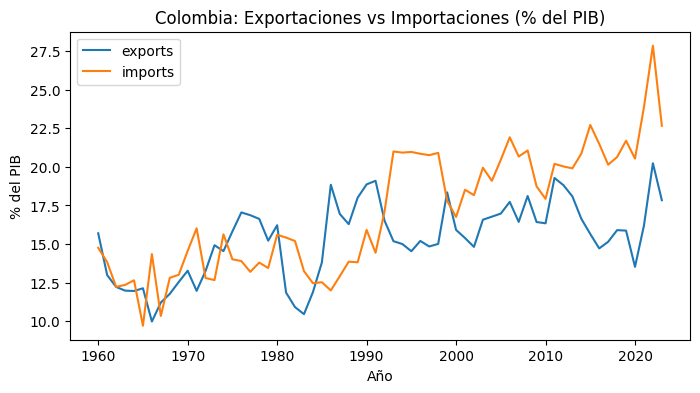

In [29]:
import matplotlib.pyplot as plt

ax = df.plot(x='year', y=['exports','imports'], figsize=(8,4), title='Colombia: Exportaciones vs Importaciones (% del PIB)')
ax.set_xlabel('Año')
ax.set_ylabel('% del PIB')
plt.show()


In [32]:
query = """
SELECT 
    g.country_name,
    f.year,
    f.value AS indicador_valor,
    f.indicator_code,      -- ahora legible: importaciones, inflacion, etc.
    i.indicator_name       -- nombre descriptivo en español
FROM fact_indicators f
JOIN dim_geo g ON f.country_code = g.country_code
JOIN dim_indicator i ON f.indicator_code = i.indicator_code
WHERE g.is_aggregate = 0
  AND f.year BETWEEN 2010 AND 2022
ORDER BY f.year, f.indicator_code;"""